In [2]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras import layers, models

IMG_SIZE = (160, 160)
BATCH_SIZE = 32
EPOCHS = 20
DATASET_PATH = r"C:\Users\hariv\Downloads\dogs_cats_dataset"

train_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

print("Class names:", train_ds.class_names)  # MUST be ['cats','dogs']

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)

data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.2),
    tf.keras.layers.RandomZoom(0.2),
    tf.keras.layers.RandomContrast(0.2),
])

base_model = tf.keras.applications.MobileNetV2(
    input_shape=(160,160,3),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False

model = tf.keras.Sequential([
    data_augmentation,
    tf.keras.layers.Rescaling(1./127.5, offset=-1),
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dropout(0.4),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.fit(train_ds, validation_data=val_ds, epochs=20)

model.save("cat_dog_model.h5")

print("MODEL SAVED")





Found 8 files belonging to 2 classes.
Using 7 files for training.
Found 8 files belonging to 2 classes.
Using 1 files for validation.
Class names: ['cats', 'dogs']
Epoch 1/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step - accuracy: 0.7143 - loss: 0.5084 - val_accuracy: 0.0000e+00 - val_loss: 0.8514
Epoch 2/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 381ms/step - accuracy: 0.5714 - loss: 0.8170 - val_accuracy: 0.0000e+00 - val_loss: 0.8361
Epoch 3/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 390ms/step - accuracy: 0.5714 - loss: 0.8093 - val_accuracy: 0.0000e+00 - val_loss: 0.8381
Epoch 4/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 366ms/step - accuracy: 0.7143 - loss: 0.5036 - val_accuracy: 0.0000e+00 - val_loss: 0.8511
Epoch 5/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 364ms/step - accuracy: 0.7143 - loss: 0.5709 - val_accuracy: 0.0000e+00 - val_loss: 0.8474
Epoch 6/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 332ms/step - accuracy: 1.0000 - loss: 0.3895 - val_accuracy: 0.0000e+00 - val_loss: 0.8380
Epoch 7/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 333ms/step - accurac

MODEL SAVED


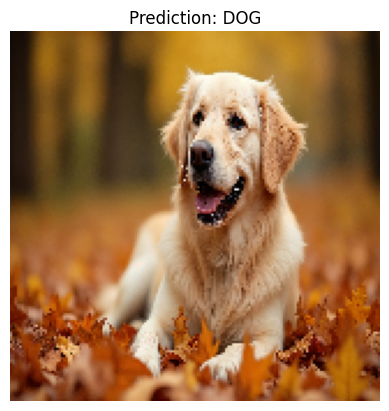

DOG


In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# Load model
model = tf.keras.models.load_model("cat_dog_model.h5")

IMG_SIZE = (160, 160)

IMAGE_PATH = r"C:\Users\hariv\Downloads\dogs_cats_dataset\dogs\dog1.jpg"

def detect_image(img_path):
    img = tf.keras.utils.load_img(img_path, target_size=IMG_SIZE)
    img = tf.keras.utils.img_to_array(img)
    img = np.expand_dims(img, axis=0)

    # get result
    result = model.predict(img, verbose=0)[0][0]

    # FINAL OUTPUT ONLY
    label = "DOG" if result > 0.5 else "CAT"
    return label

label = detect_image(IMAGE_PATH)
img = tf.keras.utils.load_img(IMAGE_PATH, target_size=IMG_SIZE)
plt.imshow(img)
plt.axis('off')
plt.title(f"Prediction: {label}")
plt.show()
print(label)

In [6]:
import os

path = r"C:\Users\hariv\Downloads\dogs_cats_dataset"

for folder in os.listdir(path):
    folder_path = os.path.join(path, folder)

    if os.path.isdir(folder_path):
        print(f"\nChecking: {folder}")

        files = os.listdir(folder_path)
        print("Total images:", len(files))

        print("Sample:", files[:5])


Checking: cats
Total images: 4
Sample: ['cat1.jpg', 'cat2.jpg', 'cat3.jpg', 'cat4.jpg']

Checking: dogs
Total images: 4
Sample: ['dog1.jpg', 'dog2.jpg', 'dog3.jpg', 'dog4.jpg']


In [ ]:
from PARA_DEFAULT import ParaDefaultModel

# Load model
model = ParaDefaultModel()
model.load()

# Generate text
output = model.generate_text("Learning to write", num_words=10)
print(output)

ModuleNotFoundError: No module named 'PARA_DEFAULT'